In [60]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.makedirs("artifacts", exist_ok=True)
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss
    FAISS_AVAILABLE = True  # type: ignore
except Exception:
    FAISS_AVAILABLE = False
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

NumPy: 2.0.2
Pandas: 2.2.2
FAISS доступен: True
sentence-transformers доступен: True


In [61]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


In [62]:
df = pd.read_csv("text.csv")
print(f'число документов: {len(df)}')
print(f'примеры документов\n:{df[:5]}')
documents = df.to_dict(orient='records')


число документов: 18
примеры документов
:    doc_id                               title  \
0  msf_001     Что такое Metasploit Framework?   
1  msf_002     Установка и запуск в Kali Linux   
2  msf_003         Основные команды msfconsole   
3  msf_004           Типы модулей в Metasploit   
4  msf_005  Работа с payloads: reverse vs bind   

                                             content  
0  Metasploit Framework (MSF) — это открытая плат...  
1  В Kali Linux Metasploit предустановлен. Запуск...  
2  Ключевые команды консоли: search <keyword> — п...  
3  MSF использует 6 основных типов модулей: 1. Ex...  
4  Payload — код, выполняемый после успешной эксп...  


Пояснение что это за предметная область и почему по ней разумно строить retrieval / mini-RAG.

In [63]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["content"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=22, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 64


,doc_id,title,chunk_id,chunk_text,n_words
0,msf_001,Что такое Metasploit Framework?,0,Metasploit Framework (MSF) — это открытая плат...,22
1,msf_001,Что такое Metasploit Framework?,1,"на проникновение, аудита безопасности и исслед...",22
2,msf_001,Что такое Metasploit Framework?,2,пост-эксплуатации и обхода защит. Важно: испол...,22
3,msf_001,Что такое Metasploit Framework?,3,и при наличии письменного разрешения владельца...,7
4,msf_002,Установка и запуск в Kali Linux,0,В Kali Linux Metasploit предустановлен. Запуск...,22
5,msf_002,Установка и запуск в Kali Linux,1,install metasploit-framework). Для работы с БД...,22
6,msf_002,Установка и запуск в Kali Linux,2,"а не root, чтобы минимизировать риски при ошиб...",21
7,msf_003,Основные команды msfconsole,0,Ключевые команды консоли: search <keyword> — п...,22
8,msf_003,Основные команды msfconsole,1,/ show payloads — просмотр настроек; set <VAR>...,22
9,msf_003,Основные команды msfconsole,2,/ run — запуск; sessions -l — список активных ...,22


пояснить выбранные параметры (chunk_size, overlap или их аналог).

In [64]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [65]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (64, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [66]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [67]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


In [68]:
# Проверяем retrieval на нескольких запросах.
example_queries = [
    "Что такое Metasploit?",
    "Как запустить Metasploit в Kali Linux и обновить его?",
    "Какие типы модулей есть в Metasploit и чем они отличаются?",

]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Что такое Metasploit?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,msf_001,Что такое Metasploit Framework?,0,0.6059,Metasploit Framework (MSF) — это открытая плат...
1,2,msf_015,Интеграция с NMAP и другими инструментами,0,0.5710,Metasploit эффективно работает в связке: 1. Ск...
2,3,msf_002,Установка и запуск в Kali Linux,0,0.5518,В Kali Linux Metasploit предустановлен. Запуск...


### Запрос: `Как запустить Metasploit в Kali Linux и обновить его?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,msf_002,Установка и запуск в Kali Linux,0,0.5984,В Kali Linux Metasploit предустановлен. Запуск...
1,2,msf_001,Что такое Metasploit Framework?,2,0.5504,пост-эксплуатации и обхода защит. Важно: испол...
2,3,msf_015,Интеграция с NMAP и другими инструментами,0,0.4696,Metasploit эффективно работает в связке: 1. Ск...


### Запрос: `Какие типы модулей есть в Metasploit и чем они отличаются?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,msf_015,Интеграция с NMAP и другими инструментами,0,0.5088,Metasploit эффективно работает в связке: 1. Ск...
1,2,msf_001,Что такое Metasploit Framework?,0,0.5046,Metasploit Framework (MSF) — это открытая плат...
2,3,msf_002,Установка и запуск в Kali Linux,0,0.4680,В Kali Linux Metasploit предустановлен. Запуск...


Контрольные запросы

In [69]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое Metasploit Framework и для чего он используется?",
        "relevant_doc_ids": ["msf_001"]
    },
    {
        "query_id": "q02",
        "query": "Как запустить Metasploit в Kali Linux и обновить его?",
        "relevant_doc_ids": ["msf_002"]
    },
    {
        "query_id": "q03",
        "query": "Какая команда в msfconsole показывает список доступных опций модуля?",
        "relevant_doc_ids": ["msf_003"]
    },
    {
        "query_id": "q04",
        "query": "Какие типы модулей есть в Metasploit и чем они отличаются?",
        "relevant_doc_ids": ["msf_004"]
    },
    {
        "query_id": "q05",
        "query": "В чём разница между reverse TCP и bind TCP payload? Когда какой использовать?",
        "relevant_doc_ids": ["msf_005"]
    },
    {
        "query_id": "q06",
        "query": "Как просканировать порты на целевой машине с помощью auxiliary-модулей?",
        "relevant_doc_ids": ["msf_006"]
    },
    {
        "query_id": "q07",
        "query": "Как проэксплуатировать уязвимость vsftpd 2.3.4 на Metasploitable 2?",
        "relevant_doc_ids": ["msf_007"]
    },
    {
        "query_id": "q08",
        "query": "Как управлять активными сессиями и что такое Meterpreter?",
        "relevant_doc_ids": ["msf_008"]
    },
    {
        "query_id": "q09",
        "query": "Какие способы обхода антивирусов поддерживаются в Metasploit?",
        "relevant_doc_ids": ["msf_009"]
    },
    {
        "query_id": "q10",
        "query": "Как сгенерировать reverse shell для Linux через msfvenom?",
        "relevant_doc_ids": ["msf_010"]
    },
    {
        "query_id": "q11",
        "query": "Как инициализировать базу данных в Metasploit и сохранить результаты сканирования?",
        "relevant_doc_ids": ["msf_011"]
    },
    {
        "query_id": "q12",
        "query": "Какие модули post-exploitation использовать для сбора данных после взлома?",
        "relevant_doc_ids": ["msf_012"]
    }
]

In [70]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["content"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [71]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

for q_dict in benchmark_queries:
    query_text = q_dict["query"]
    display(Markdown(f"### Запрос: {query_text}"))
    display(search_chunks(query_text, artifacts=artifacts, top_k=5)[["rank", "score", "doc_id", "title", "chunk_text"]])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 52


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,msf_001,Что такое Metasploit Framework?,msf_001_chunk_0,0,Metasploit Framework (MSF) — это открытая плат...
1,msf_001,Что такое Metasploit Framework?,msf_001_chunk_1,1,безопасности и исследований уязвимостей. Включ...
2,msf_001,Что такое Metasploit Framework?,msf_001_chunk_2,2,только в изолированных лабораторных средах (на...
3,msf_002,Установка и запуск в Kali Linux,msf_002_chunk_0,0,В Kali Linux Metasploit предустановлен. Запуск...
4,msf_002,Установка и запуск в Kali Linux,msf_002_chunk_1,1,работы с БД: msfdb init → db_status. Рекоменда...


### Запрос: Что такое Metasploit Framework и для чего он используется?

...

,rank,score,doc_id,title,chunk_text
0,1,0.809188,msf_010,Генерация пейлоадов через msfvenom,msfvenom — утилита для создания и кодирования ...
1,2,0.460232,msf_002,Установка и запуск в Kali Linux,В Kali Linux Metasploit предустановлен. Запуск...
2,3,0.447439,msf_011,Работа с базой данных Metasploit,MSF поддерживает PostgreSQL для хранения резул...
3,4,0.439252,msf_010,Генерация пейлоадов через msfvenom,elf > shell.elf. Windows exe с кодированием: m...
4,5,0.419147,msf_004,Типы модулей в Metasploit,MSF использует 6 основных типов модулей: 1. Ex...


### Запрос: Как инициализировать базу данных в Metasploit и сохранить результаты сканирования?

,rank,score,doc_id,title,chunk_text
0,1,0.671222,msf_015,Интеграция с NMAP и другими инструментами,Metasploit эффективно работает в связке: 1. Ск...
1,2,0.541742,msf_001,Что такое Metasploit Framework?,Metasploit Framework (MSF) — это открытая плат...
2,3,0.493673,msf_002,Установка и запуск в Kali Linux,В Kali Linux Metasploit предустановлен. Запуск...
3,4,0.449436,msf_011,Работа с базой данных Metasploit,MSF поддерживает PostgreSQL для хранения резул...
4,5,0.410810,msf_017,Ресурсы для обучения и отладки,Полезные источники: Официальная документация d...


### Запрос: Какие модули post-exploitation использовать для сбора данных после взлома?

,rank,score,doc_id,title,chunk_text
0,1,0.618280,msf_006,Сканирование и разведка с auxiliary,"Модули auxiliary не эксплуатируют уязвимости, ..."
1,2,0.582536,msf_004,Типы модулей в Metasploit,"на целевой системе (reverse/bind shell, meterp..."
2,3,0.558068,msf_012,Пост-эксплуатация: сбор данных,После получения доступа используйте модули pos...
3,4,0.554447,msf_004,Типы модулей в Metasploit,MSF использует 6 основных типов модулей: 1. Ex...
4,5,0.517097,msf_007,Эксплуатация уязвимости: пошаговый пример,Пример атаки на vsftpd 2.3.4 (Metasploitable 2...


In [72]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое Metasploit Framework и для чего он и...,msf_001,"msf_001, msf_015, msf_002",1,1.0,1.000000,1.0
1,q02,Как запустить Metasploit в Kali Linux и обнови...,msf_002,"msf_001, msf_002, msf_015",1,1.0,0.500000,2.0
2,q03,Какая команда в msfconsole показывает список д...,msf_003,"msf_004, msf_016, msf_002",0,0.0,0.000000,NaN
3,q04,Какие типы модулей есть в Metasploit и чем они...,msf_004,"msf_015, msf_001, msf_004",1,1.0,0.333333,3.0
4,q05,В чём разница между reverse TCP и bind TCP pay...,msf_005,msf_005,1,1.0,1.000000,1.0
5,q06,Как просканировать порты на целевой машине с п...,msf_006,"msf_005, msf_006, msf_002",1,1.0,0.500000,2.0
6,q07,Как проэксплуатировать уязвимость vsftpd 2.3.4...,msf_007,"msf_007, msf_015, msf_001",1,1.0,1.000000,1.0
7,q08,Как управлять активными сессиями и что такое M...,msf_008,"msf_008, msf_003",1,1.0,1.000000,1.0
8,q09,Какие способы обхода антивирусов поддерживаютс...,msf_009,"msf_015, msf_001, msf_017",0,0.0,0.000000,NaN
9,q10,Как сгенерировать reverse shell для Linux чере...,msf_010,"msf_010, msf_002, msf_011",1,1.0,1.000000,1.0


,metric,value
0,mean_hit@3,0.750000
1,mean_recall@3,0.750000
2,mean_MRR@3,0.555556


In [73]:
cols_to_keep = ["query", "relevant_doc_ids", "predicted_doc_ids", "hit@3"]
retrieval_eval_df = baseline_eval_k3[cols_to_keep].copy()

retrieval_eval_df = retrieval_eval_df.rename(columns={
    "relevant_doc_ids": "expected_source",
    "predicted_doc_ids": "retrieved_sources",
    "hit@3": "hit_at_k"
})

output_file = "artifacts/retrieval_eval.csv"
retrieval_eval_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Файл '{output_file}' успешно сохранен.")

Файл 'artifacts/retrieval_eval.csv' успешно сохранен.


In [74]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [20, 50
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg,
        overlap=5,
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg,
            "overlap": 5,
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,20,5,70,SentenceTransformer: sentence-transformers/par...,0.75,0.75,0.583333
1,50,5,32,SentenceTransformer: sentence-transformers/par...,0.75,0.75,0.583333


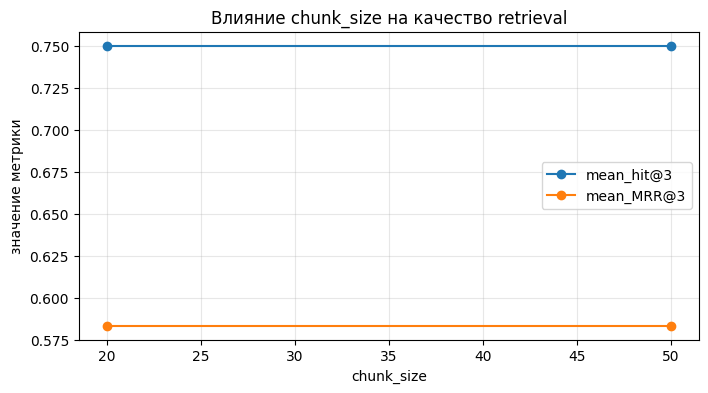

In [75]:
# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [76]:
new_docs = [
    {
        "doc_id": "msf_019",
        "title": "Работа с Workspaces в Metasploit",
        "content": """Workspaces позволяют изолировать данные разных пентест-проектов в одной БД Metasploit.
        Команды: workspace -a <name> (создать), workspace -r <name> (переключиться), workspace -d <name> (удалить).
        Все хосты, сервисы, vulns привязываются к активному workspace.
        Используйте для разделения: "client_A_prod", "client_B_lab", "internal_audit_2024".
        Проверка текущего: workspace (без аргументов). Экспорт: db_export -w <name> -f xml -o report.xml."""
    },
    {
        "doc_id": "msf_020",
        "title": "Автоматизация через Resource-скрипты (.rc)",
        "content": """Resource-скрипты — это файлы с командами msfconsole для автоматизации рутинных задач.
        Создайте файл scan.rc:
        ```
        db_connect user:pass@127.0.0.1/msf
        workspace -a target_scan
        db_nmap -sV -sC 192.168.1.0/24
        services -s --up -p 80,443
        exit
        ```
        Запуск: msfconsole -r scan.rc или в консоли: resource scan.rc.
        Используйте для: повторяющихся сканирований, демо-сценариев, CI/CD-пайплайнов пентеста."""
    },
    {
        "doc_id": "msf_021",
        "title": "Как выбирать эксплойт: рейтинг надёжности и проверка",
        "content": """Не все эксплойты одинаково стабильны. Обращайте внимание на:
        1. Ranking в модуле: excellent/great/good/normal/average/low (показывает риск креша цели).
        2. Команду check: run check перед exploit — проверит уязвимость без эксплуатации.
        3. Arch и Platform: linux/x86 ≠ windows/x64 — несовместимый payload не сработает.
        4. Session type: shell vs meterpreter — второй даёт больше возможностей пост-эксплуатации.
        Совет: начинайте с эксплойтов ранга excellent/great для учебных лабораторий."""
    }
]

updated_documents = documents + new_docs

display(pd.DataFrame(new_docs)[["doc_id", "title"]])

,doc_id,title
0,msf_019,Работа с Workspaces в Metasploit
1,msf_020,Автоматизация через Resource-скрипты (.rc)
2,msf_021,Как выбирать эксплойт: рейтинг надёжности и пр...


In [77]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

before_update_eval = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое Metasploit Framework и для чего он и...,msf_001,"msf_001, msf_015, msf_002",1,1.0,1.000000,1.0,"msf_001, msf_015, msf_002",1,1.0,1.000000,1.0
1,q02,Как запустить Metasploit в Kali Linux и обнови...,msf_002,"msf_001, msf_002, msf_015",1,1.0,0.500000,2.0,"msf_001, msf_002, msf_015",1,1.0,0.500000,2.0
2,q03,Какая команда в msfconsole показывает список д...,msf_003,"msf_004, msf_016, msf_002",0,0.0,0.000000,NaN,"msf_004, msf_016, msf_002",0,0.0,0.000000,NaN
3,q04,Какие типы модулей есть в Metasploit и чем они...,msf_004,"msf_015, msf_001, msf_004",1,1.0,0.333333,3.0,"msf_015, msf_001, msf_004",1,1.0,0.333333,3.0
4,q05,В чём разница между reverse TCP и bind TCP pay...,msf_005,msf_005,1,1.0,1.000000,1.0,msf_005,1,1.0,1.000000,1.0
5,q06,Как просканировать порты на целевой машине с п...,msf_006,"msf_005, msf_006, msf_002",1,1.0,0.500000,2.0,"msf_005, msf_006, msf_002",1,1.0,0.500000,2.0
6,q07,Как проэксплуатировать уязвимость vsftpd 2.3.4...,msf_007,"msf_007, msf_015, msf_001",1,1.0,1.000000,1.0,"msf_007, msf_015, msf_001",1,1.0,1.000000,1.0
7,q08,Как управлять активными сессиями и что такое M...,msf_008,"msf_008, msf_003",1,1.0,1.000000,1.0,"msf_008, msf_021",1,1.0,1.000000,1.0
8,q09,Какие способы обхода антивирусов поддерживаютс...,msf_009,"msf_015, msf_001, msf_017",0,0.0,0.000000,NaN,"msf_015, msf_001, msf_017",0,0.0,0.000000,NaN
9,q10,Как сгенерировать reverse shell для Linux чере...,msf_010,"msf_010, msf_002, msf_011",1,1.0,1.000000,1.0,"msf_010, msf_002, msf_011",1,1.0,1.000000,1.0


,metric,before_update,after_update,delta
0,mean_hit@3,0.750000,0.750000,0.0
1,mean_recall@3,0.750000,0.750000,0.0
2,mean_MRR@3,0.555556,0.555556,0.0


In [78]:
result_df = comparison_df.rename(columns={
    'predicted_doc_ids_before': 'before_retrieved_sources',
    'predicted_doc_ids_after': 'after_retrieved_sources'
})[['query', 'before_retrieved_sources', 'after_retrieved_sources']]

result_df['changed'] = result_df['before_retrieved_sources'] != result_df['after_retrieved_sources']

output_file = 'artifacts/retrieval_before_after_update.csv'
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')

In [80]:
def build_context_from_retrieval(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [81]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [82]:
query = "Как использовать Metasploit?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Как использовать Metasploit?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.651136,msf_015,Интеграция с NMAP и другими инструментами,msf_015_chunk_0,Metasploit эффективно работает в связке: 1. Ск...
1,2,0.564219,msf_001,Что такое Metasploit Framework?,msf_001_chunk_0,Metasploit Framework (MSF) — это открытая плат...
2,3,0.486823,msf_002,Установка и запуск в Kali Linux,msf_002_chunk_0,В Kali Linux Metasploit предустановлен. Запуск...


[Источник: msf_015 | Интеграция с NMAP и другими инструментами | score=0.6511]
Metasploit эффективно работает в связке: 1. Сканирование в NMAP с сохранением в БД: db_nmap -sV -sC -oA scan_metasploitable 192.168.1.20; 2. Импорт результатов в MSF: db_import scan_metasploitable.xml; 3. Поиск

[Источник: msf_001 | Что такое Metasploit Framework? | score=0.5642]
Metasploit Framework (MSF) — это открытая платформа для разработки, тестирования и выполнения эксплойтов. Создана для легального тестирования на проникновение, аудита безопасности и исследований уязвимостей. Включает более 2000 эксплойтов,

[Источник: msf_002 | Установка и запуск в Kali Linux | score=0.4868]
В Kali Linux Metasploit предустановлен. Запуск: msfconsole — интерактивная консоль. Обновление: msfupdate (или apt update && apt install metasploit-framework). Для работы с БД: msfdb init → db_status. Рекомендация:


In [83]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [84]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [85]:
rag_result = mini_rag_answer(
    "Как использовать Metasploit?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Как использовать Metasploit?

**Ответ:** Metasploit эффективно работает в связке: 1. В Kali Linux Metasploit предустановлен.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.651136,msf_015,Интеграция с NMAP и другими инструментами,msf_015_chunk_0,Metasploit эффективно работает в связке: 1. Ск...
1,2,0.564219,msf_001,Что такое Metasploit Framework?,msf_001_chunk_0,Metasploit Framework (MSF) — это открытая плат...
2,3,0.486823,msf_002,Установка и запуск в Kali Linux,msf_002_chunk_0,В Kali Linux Metasploit предустановлен. Запуск...


In [86]:
def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

In [87]:
evaluation_df = evaluate_mini_rag(benchmark_queries[:5], artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,rag_answer
0,q01,Что такое Metasploit Framework и для чего он и...,msf_001,"msf_001, msf_015, msf_002",1,Metasploit Framework (MSF) — это открытая плат...
1,q02,Как запустить Metasploit в Kali Linux и обнови...,msf_002,"msf_001, msf_002, msf_015",1,В Kali Linux Metasploit предустановлен. только...
2,q03,Какая команда в msfconsole показывает список д...,msf_003,"msf_004, msf_016, msf_002",0,Запуск: msfconsole — интерактивная консоль.
3,q04,Какие типы модулей есть в Metasploit и чем они...,msf_004,"msf_015, msf_001, msf_004",1,Metasploit эффективно работает в связке: 1. Me...
4,q05,В чём разница между reverse TCP и bind TCP pay...,msf_005,"msf_005, msf_005, msf_005",1,Bind TCP — атакующий подключается к открытому ...


In [88]:
rag_examples_df = evaluation_df.rename(columns={
    "query": "question",
    "rag_answer": "answer",
    "predicted_doc_ids": "retrieved_sources"
})[["question", "answer", "retrieved_sources"]]

output_file = "artifacts/rag_examples.csv"
rag_examples_df.to_csv(output_file, index=False, encoding="utf-8-sig")